In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [7]:
# Import core libraries for data handling and computation
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import imputer for handling high-missing columns
from sklearn.impute import KNNImputer

# Set a clean visual style for all plots
sns.set_style('whitegrid')

In [8]:
# Load the dataset from Drive into a pandas DataFrame
df = pd.read_csv('/content/drive/MyDrive/internship/employee_dataset.csv')

# Quick look at first few rows
df.head()

,employee_id,age,department,city,years_experience,education,monthly_hours,projects_completed,performance_score,salary
0,1358,NaN,Marketing,Mumbai,4.548379,PhD,148.223630,3,5.292149,33395.239645
1,1338,43.0,HR,Mumbai,3.315833,Bachelors,214.696638,5,6.819830,NaN
2,1328,NaN,Marketing,Delhi,5.085073,Bachelors,184.896387,6,8.198768,60324.242112
3,1014,23.0,Marketing,Pune,7.613484,Masters,189.697574,3,6.869866,63375.089773
4,1419,47.0,Sales,Lucknow,NaN,Bachelors,204.474207,6,7.101241,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   employee_id         505 non-null    int64  
 1   age                 490 non-null    float64
 2   department          505 non-null    object 
 3   city                505 non-null    object 
 4   years_experience    444 non-null    float64
 5   education           475 non-null    object 
 6   monthly_hours       505 non-null    float64
 7   projects_completed  505 non-null    int64  
 8   performance_score   465 non-null    float64
 9   salary              379 non-null    float64
dtypes: float64(5), int64(2), object(3)
memory usage: 39.6+ KB
employee_id            0.000000
age                    2.970297
department             0.000000
city                   0.000000
years_experience      12.079208
education              5.940594
monthly_hours          0.000000
projects_completed  

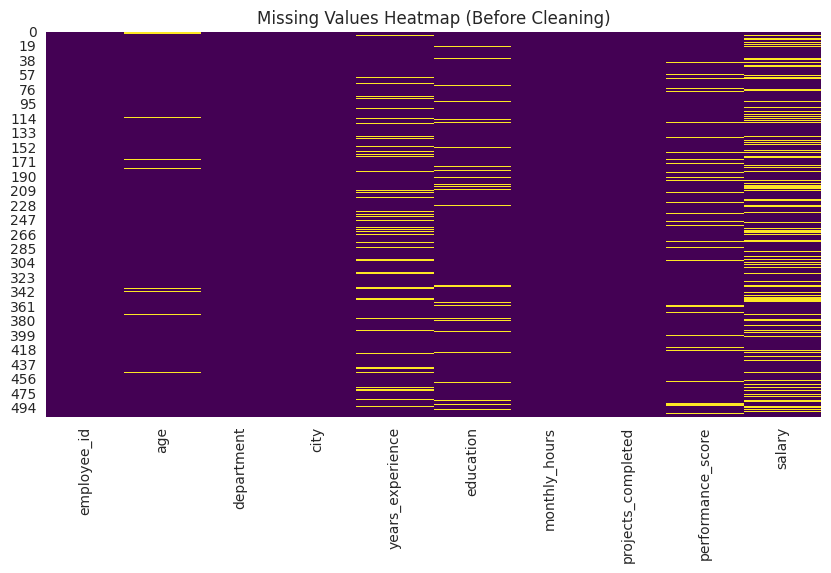

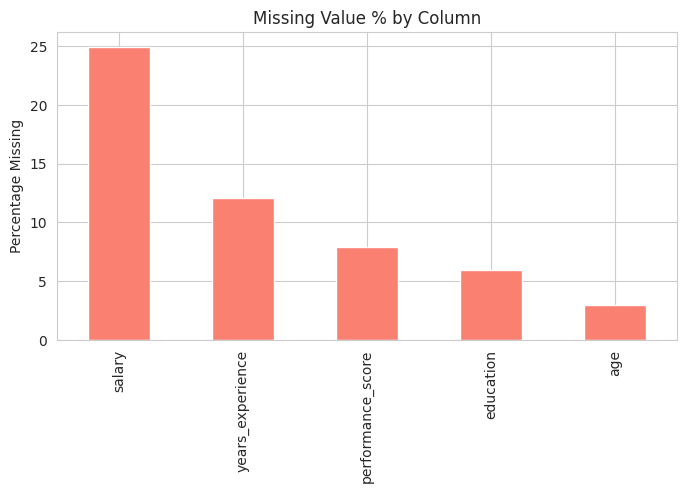

In [9]:
# Basic info: column types, non-null counts, memory usage
df.info()

# Statistical summary: mean, std, min, max, quartiles for numeric columns
df.describe()

# Calculate % missing values per column
missing_pct = df.isnull().mean() * 100
print(missing_pct)

# Visualize missing data pattern - heatmap shows where NaNs are located
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap (Before Cleaning)')
plt.show()

# Bar chart of missing % per column - easier to read than heatmap
plt.figure(figsize=(8,4))
missing_pct[missing_pct > 0].sort_values(ascending=False).plot(kind='bar', color='salmon')
plt.title('Missing Value % by Column')
plt.ylabel('Percentage Missing')
plt.show()

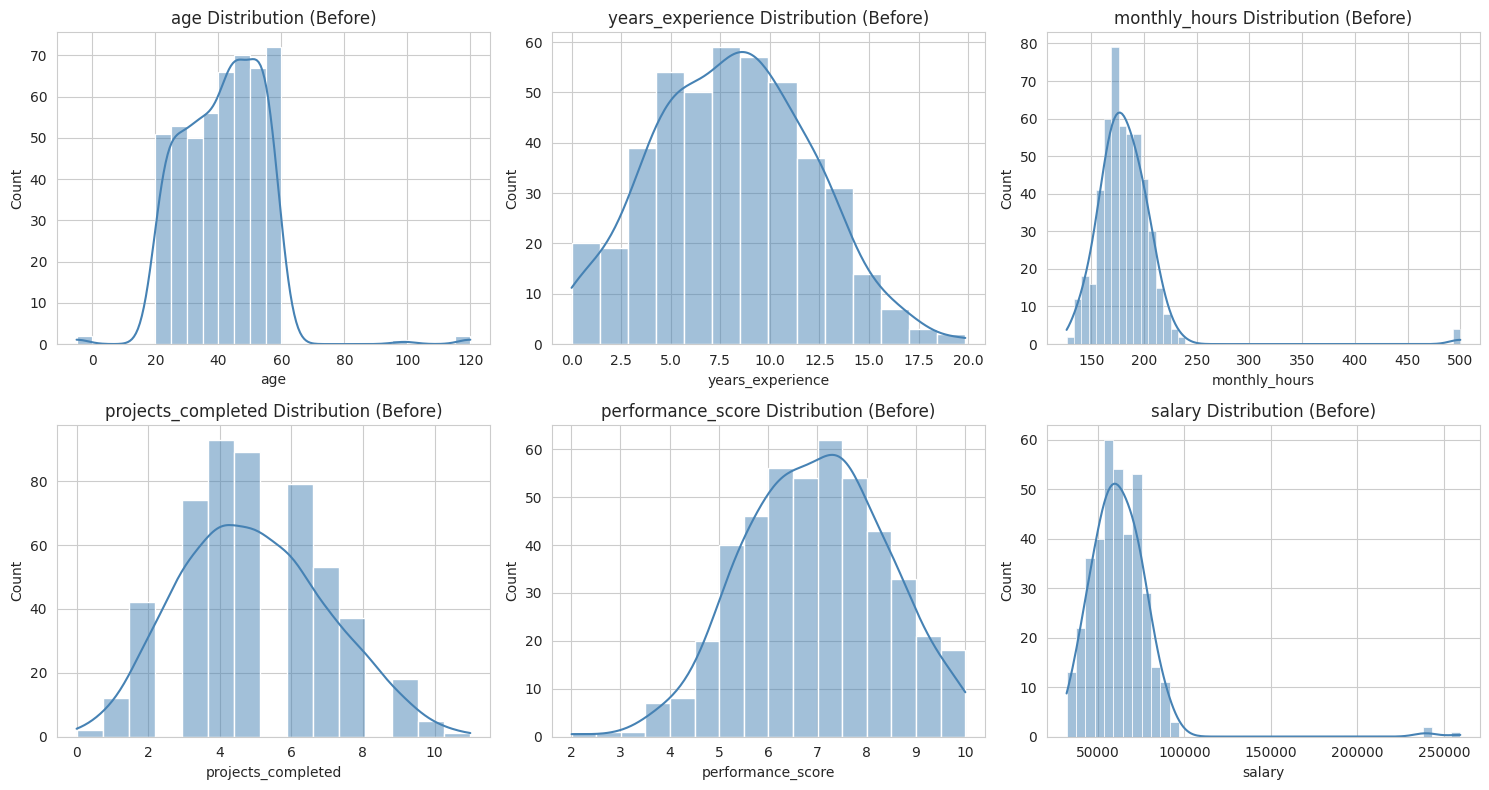

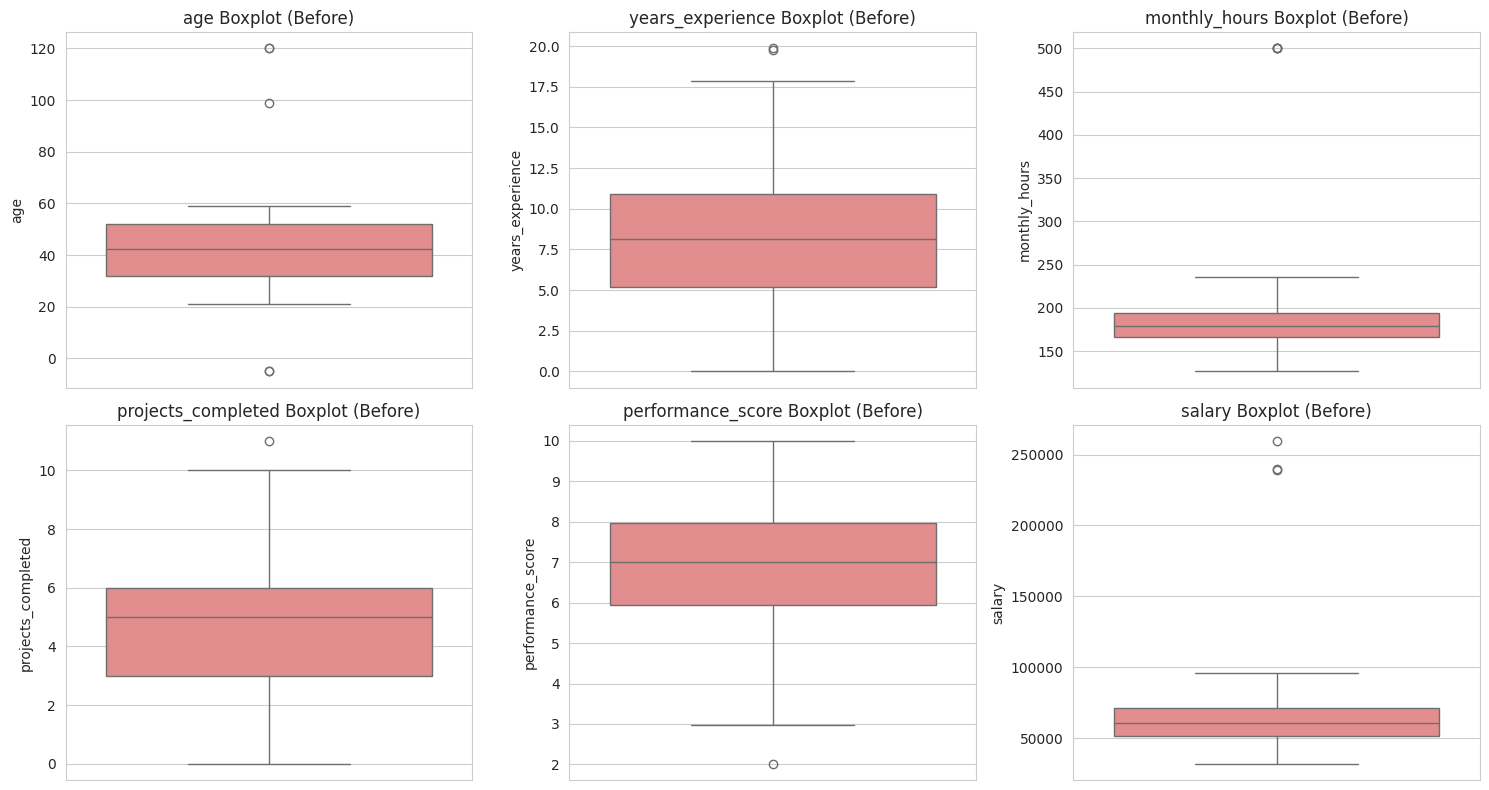

In [10]:
# Distribution plots for numeric columns BEFORE imputation/outlier handling
numeric_cols = ['age','years_experience','monthly_hours','projects_completed','performance_score','salary']

fig, axes = plt.subplots(2, 3, figsize=(15,8))
for i, col in enumerate(numeric_cols):
    ax = axes[i//3, i%3]
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue')
    ax.set_title(f'{col} Distribution (Before)')
plt.tight_layout()
plt.show()

# Boxplots to spot outliers visually BEFORE capping
fig, axes = plt.subplots(2, 3, figsize=(15,8))
for i, col in enumerate(numeric_cols):
    ax = axes[i//3, i%3]
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(f'{col} Boxplot (Before)')
plt.tight_layout()
plt.show()

In [11]:
# --- AGE: only 3% missing -> safe to fill with median (robust to outliers) ---
df['age'] = df['age'].fillna(df['age'].median())

# --- EDUCATION: categorical column -> fill with mode (most frequent category) ---
df['education'] = df['education'].fillna(df['education'].mode()[0])

# --- YEARS_EXPERIENCE: 12% missing -> median imputation (numeric, moderate missingness) ---
df['years_experience'] = df['years_experience'].fillna(df['years_experience'].median())

# --- PERFORMANCE_SCORE: 8% missing -> median imputation ---
df['performance_score'] = df['performance_score'].fillna(df['performance_score'].median())

# --- SALARY: 25% missing (>20% threshold) -> use KNN imputation ---
# KNN looks at the 5 most similar rows (based on other numeric columns)
# and estimates the missing salary from their average - smarter than a flat median here
imputer = KNNImputer(n_neighbors=5)
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

# Confirm all missing values are now handled
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
employee_id           0
age                   0
department            0
city                  0
years_experience      0
education             0
monthly_hours         0
projects_completed    0
performance_score     0
salary                0
dtype: int64


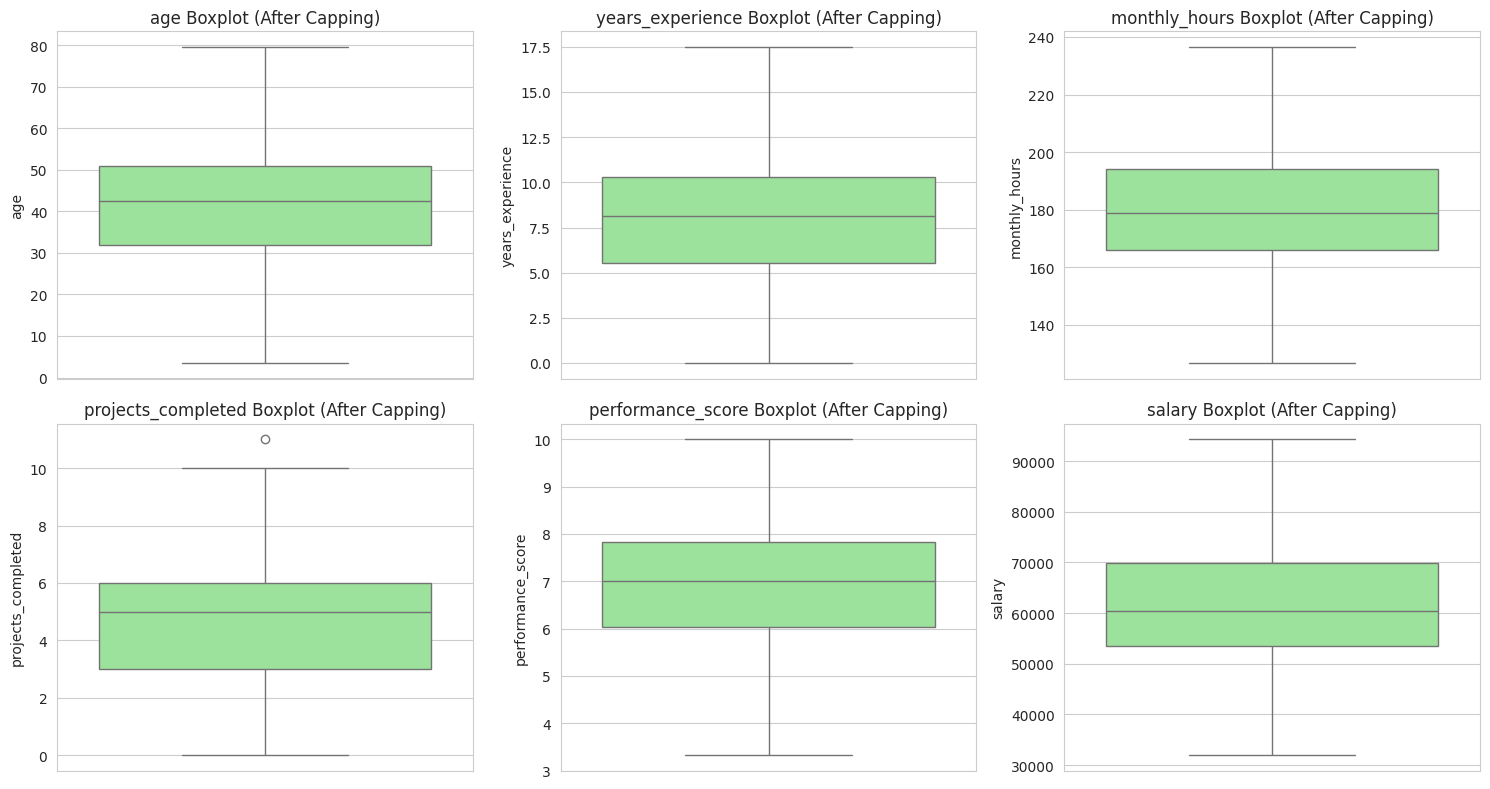

In [12]:
# Function to cap outliers using IQR method instead of deleting rows
# (deleting rows loses data; capping preserves row count and sequence)
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)          # 25th percentile
    Q3 = df[col].quantile(0.75)          # 75th percentile
    IQR = Q3 - Q1                         # Interquartile range
    lower = Q1 - 1.5 * IQR                # lower outlier boundary
    upper = Q3 + 1.5 * IQR                # upper outlier boundary
    df[col] = np.clip(df[col], lower, upper)  # cap values beyond boundaries
    return df

# Apply outlier capping to all relevant numeric columns
for col in ['age','years_experience','monthly_hours','performance_score','salary']:
    df = cap_outliers_iqr(df, col)

# Visualize boxplots AFTER capping to confirm outliers are gone
fig, axes = plt.subplots(2, 3, figsize=(15,8))
for i, col in enumerate(numeric_cols):
    ax = axes[i//3, i%3]
    sns.boxplot(y=df[col], ax=ax, color='lightgreen')
    ax.set_title(f'{col} Boxplot (After Capping)')
plt.tight_layout()
plt.show()

In [13]:
# Feature 1: Salary earned per year of experience -> shows pay efficiency
df['salary_per_exp_year'] = df['salary'] / (df['years_experience'] + 1)

# Feature 2: Productivity ratio -> projects completed relative to hours worked
df['productivity_ratio'] = df['projects_completed'] / (df['monthly_hours'] + 1)

# Feature 3: Experience level bucket -> groups continuous experience into categories
df['experience_level'] = pd.cut(
    df['years_experience'],
    bins=[0,2,5,10,50],
    labels=['Junior','Mid','Senior','Expert']
)

# Feature 4 (bonus): Interaction term between age and experience
df['age_exp_interaction'] = df['age'] * df['years_experience']

# Preview new features
df[['salary_per_exp_year','productivity_ratio','experience_level','age_exp_interaction']].head()

,salary_per_exp_year,productivity_ratio,experience_level,age_exp_interaction
0,6018.918639,0.020104,Mid,193.306092
1,12945.999517,0.023181,Mid,142.580801
2,9913.478341,0.032276,Senior,216.115614
3,7357.660039,0.015732,Senior,175.110141
4,6711.605388,0.029201,Senior,382.772767


/tmp/ipykernel_2901/3613052648.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='experience_level', data=df, ax=axes[1], palette='Set2')


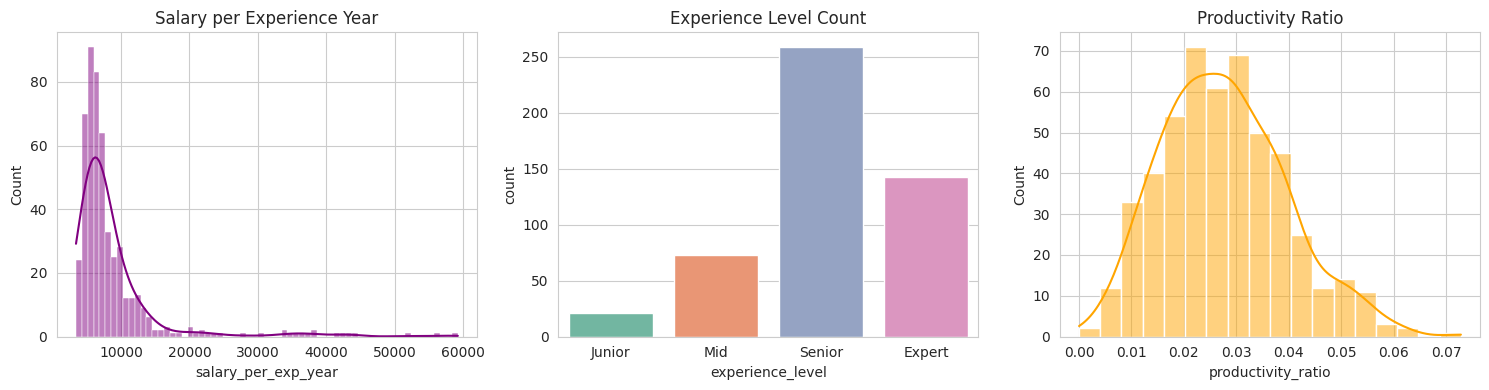

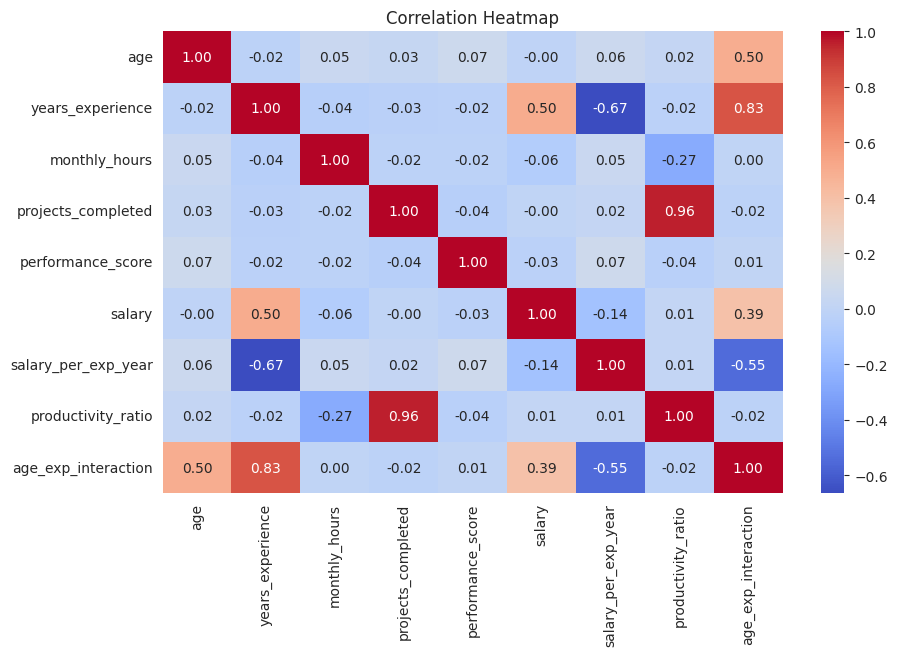

In [14]:
# Distribution of the new engineered features
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(df['salary_per_exp_year'], kde=True, ax=axes[0], color='purple')
axes[0].set_title('Salary per Experience Year')

sns.countplot(x='experience_level', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Experience Level Count')

sns.histplot(df['productivity_ratio'], kde=True, ax=axes[2], color='orange')
axes[2].set_title('Productivity Ratio')
plt.tight_layout()
plt.show()

# Correlation heatmap - check relationships between numeric variables and salary
plt.figure(figsize=(10,6))
corr = df[numeric_cols + ['salary_per_exp_year','productivity_ratio','age_exp_interaction']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [15]:
# Build absolute correlation matrix
corr_matrix = df[numeric_cols].corr().abs()

# Keep only upper triangle (avoid duplicate pairs)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find pairs with correlation > 0.8 (highly collinear)
high_corr_pairs = [(col, row, upper.loc[row,col])
                    for col in upper.columns for row in upper.index
                    if pd.notnull(upper.loc[row,col]) and upper.loc[row,col] > 0.8]

print("Highly correlated pairs (>0.8):", high_corr_pairs)
# If any found, compare each to correlation with 'salary' and drop the weaker one

Highly correlated pairs (>0.8): []


In [16]:
# One-hot encode nominal categories (avoids fake ordinal relationships)
df = pd.get_dummies(df, columns=['department','city','education','experience_level'], drop_first=True)

In [17]:
# Load a FRESH copy of the original raw dataset for comparison
# (df_original = before cleaning, df = after cleaning - already in memory)
df_original = pd.read_csv('/content/drive/MyDrive/internship/employee_dataset.csv')

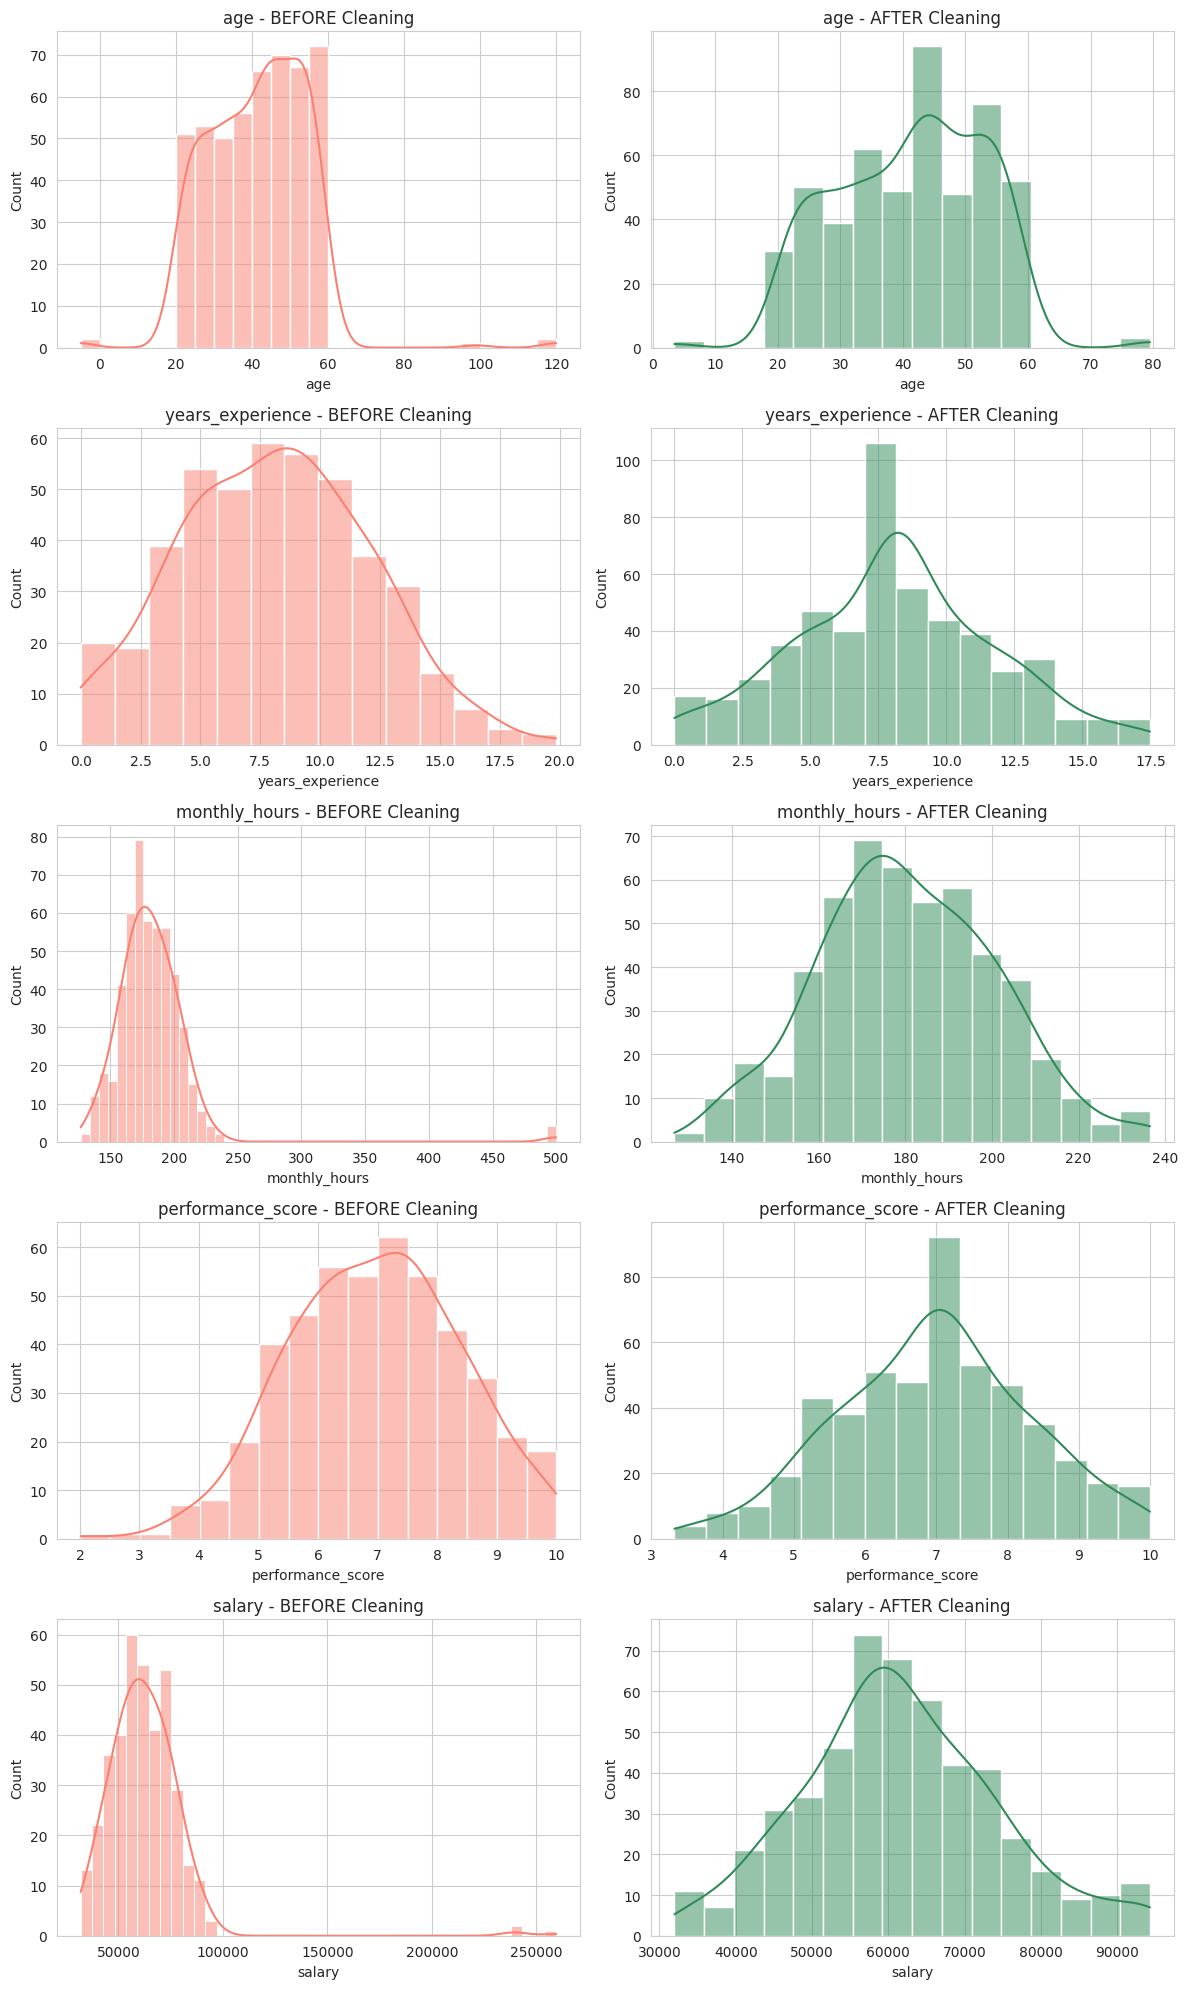

In [18]:
# Columns to compare (must exist in both - use original names before encoding)
compare_cols = ['age','years_experience','monthly_hours','performance_score','salary']

# ---- 1. Distribution comparison (Before vs After) ----
fig, axes = plt.subplots(len(compare_cols), 2, figsize=(12, 4*len(compare_cols)))

for i, col in enumerate(compare_cols):
    # Before cleaning
    sns.histplot(df_original[col].dropna(), kde=True, ax=axes[i,0], color='salmon')
    axes[i,0].set_title(f'{col} - BEFORE Cleaning')

    # After cleaning
    sns.histplot(df[col], kde=True, ax=axes[i,1], color='seagreen')
    axes[i,1].set_title(f'{col} - AFTER Cleaning')

plt.tight_layout()
plt.show()

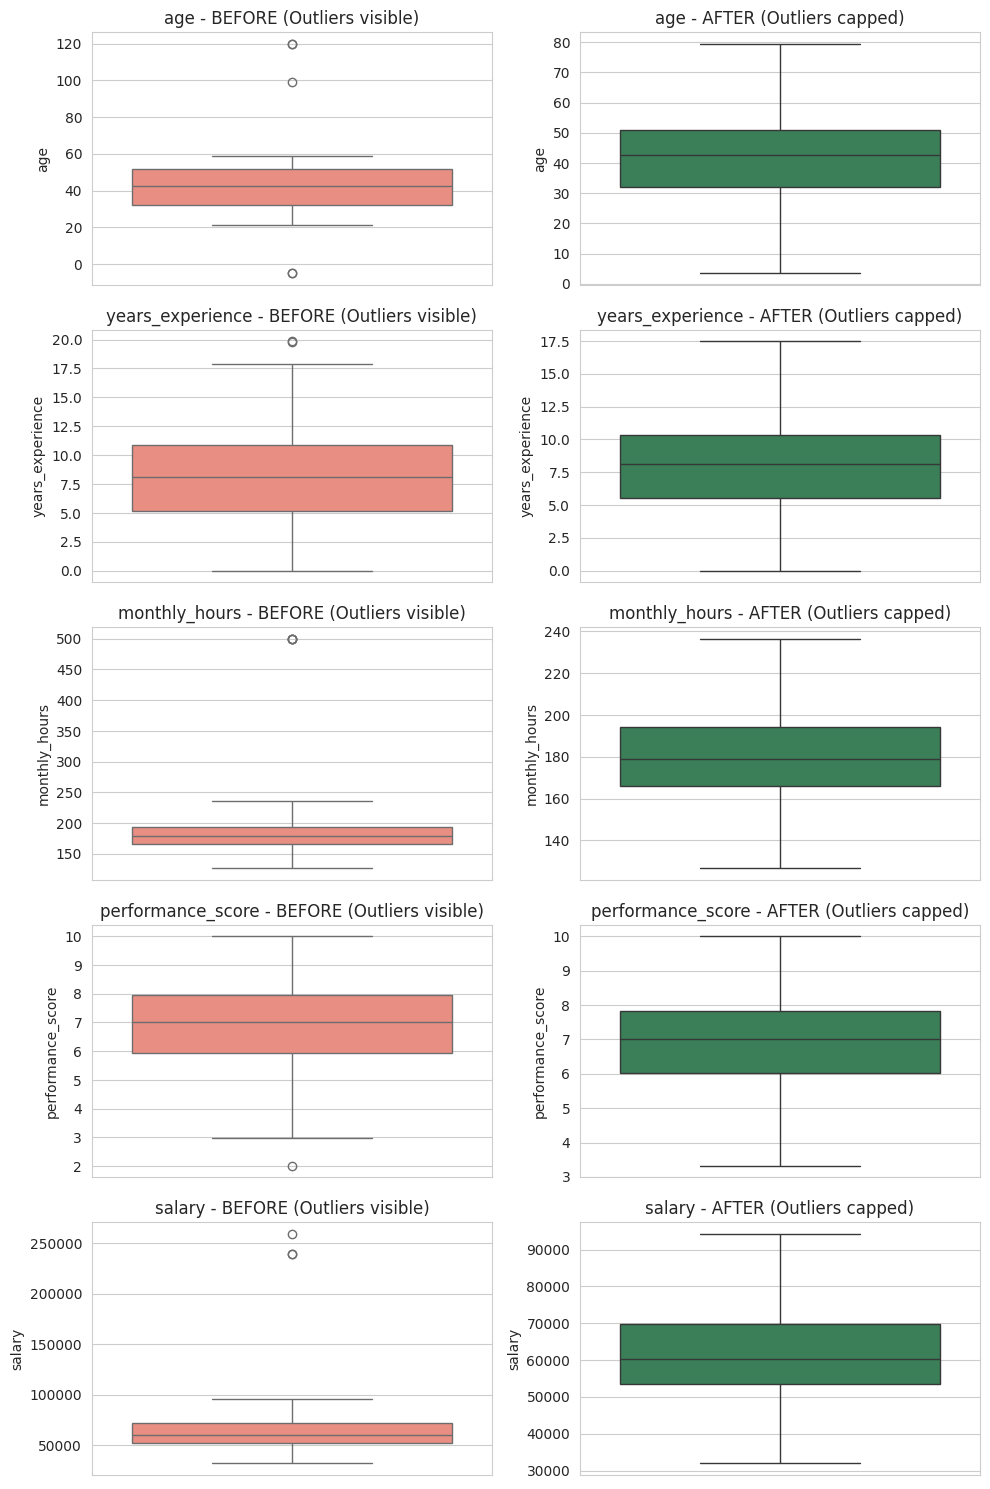

In [19]:
# ---- 2. Boxplot comparison - shows outlier impact clearly ----
fig, axes = plt.subplots(len(compare_cols), 2, figsize=(10, 3*len(compare_cols)))

for i, col in enumerate(compare_cols):
    sns.boxplot(y=df_original[col], ax=axes[i,0], color='salmon')
    axes[i,0].set_title(f'{col} - BEFORE (Outliers visible)')

    sns.boxplot(y=df[col], ax=axes[i,1], color='seagreen')
    axes[i,1].set_title(f'{col} - AFTER (Outliers capped)')

plt.tight_layout()
plt.show()

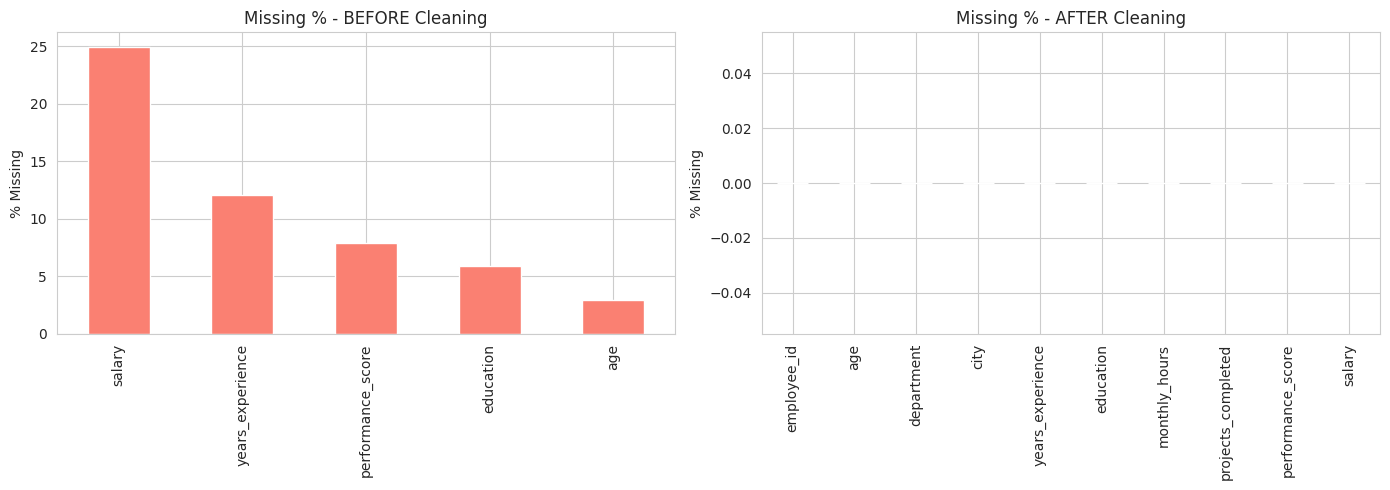

In [20]:
# ---- 3. Missing values comparison (Before vs After) ----
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Before: missing % per column
missing_before = df_original.isnull().mean()*100
missing_before[missing_before>0].sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('Missing % - BEFORE Cleaning')
axes[0].set_ylabel('% Missing')

# After: should be all zero
missing_after = df_original.columns.to_series().apply(
    lambda c: df[c].isnull().mean()*100 if c in df.columns else 0)
missing_after.sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Missing % - AFTER Cleaning')
axes[1].set_ylabel('% Missing')

plt.tight_layout()
plt.show()

In [21]:
# ---- 4. Summary stats comparison table ----
summary_before = df_original[compare_cols].describe().T
summary_after = df[compare_cols].describe().T

comparison_table = pd.concat([summary_before, summary_after], axis=1,
                               keys=['Before Cleaning', 'After Cleaning'])
print(comparison_table)

                  Before Cleaning                                            \
                            count          mean           std           min   
age                         490.0     41.289796     12.991963     -5.000000   
years_experience            444.0      8.086145      3.949346      0.000000   
monthly_hours               505.0    182.405482     34.701934    126.713354   
performance_score           465.0      6.965106      1.424284      2.012866   
salary                      379.0  62747.556422  21251.847723  31969.279309   

                                                                            \
                            25%           50%           75%            max   
age                   32.000000     42.500000     52.000000     120.000000   
years_experience       5.198821      8.144101     10.880978      19.860041   
monthly_hours        166.156956    178.746710    194.286379     500.000000   
performance_score      5.952267      7.002069      7.961

In [22]:
# Export final cleaned dataset back to Drive
df.to_csv('/content/drive/MyDrive/internship/employee_dataset_cleaned.csv', index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
